# Attention from scratch

A small PyTorch learning experiment for following the attention equation one operation at a time. It uses synthetic vectors only; it does not train a model.

## 1. What I wanted to understand

I wanted to make the path from an input tensor to contextual output concrete:

`X → Q/K/V projections → QKᵀ → divide by √d_k → softmax → attention weights → weighted sum of V`

The related notes are [Attention](../../concepts/attention.md), [Transformers](../../concepts/transformers.md), and the original-paper study's [attention mechanics](../../papers/nlp-llms/attention-is-all-you-need/attention-mechanics.md).

In [1]:
%matplotlib inline

import math
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import torch
from torch import nn

torch.manual_seed(7)
plt.rcParams['figure.dpi'] = 120

figures_dir = Path('figures')
figures_dir.mkdir(exist_ok=True)

print(f'PyTorch version: {torch.__version__}')

PyTorch version: 2.13.0


## 2. From the equation to code

For one attention head, the equation is:

`Attention(Q, K, V) = softmax(QKᵀ / √d_k) V`

The function below follows that order directly. The final two dimensions are the sequence positions and the per-head feature dimension.

In [2]:
def scaled_dot_product_attention(query, key, value, mask=None):
    # query, key, value: [batch, heads, seq_len, d_head]
    scores = query @ key.transpose(-2, -1)
    scores = scores / math.sqrt(query.size(-1))

    if mask is not None:
        scores = scores.masked_fill(~mask, float('-inf'))

    weights = torch.softmax(scores, dim=-1)
    output = weights @ value
    return output, weights, scores

## 3. Q, K and V

Each input token is projected three times. Here the synthetic sequence has four named positions. The projections are random but deterministic, so the plots are reproducible. For multi-head attention, each projection is reshaped into two smaller heads.

In [3]:
tokens = ['token 1', 'token 2', 'token 3', 'token 4']
batch_size, seq_len, d_model, heads = 1, 4, 8, 2
d_head = d_model // heads

# X: [batch, seq_len, d_model]
X = torch.randn(batch_size, seq_len, d_model)
q_projection = nn.Linear(d_model, d_model, bias=False)
k_projection = nn.Linear(d_model, d_model, bias=False)
v_projection = nn.Linear(d_model, d_model, bias=False)

# Q/K/V: [batch, heads, seq_len, d_head]
Q = q_projection(X).view(batch_size, seq_len, heads, d_head).transpose(1, 2)
K = k_projection(X).view(batch_size, seq_len, heads, d_head).transpose(1, 2)
V = v_projection(X).view(batch_size, seq_len, heads, d_head).transpose(1, 2)

print(f'X: {list(X.shape)}')
print(f'Q: {list(Q.shape)}')
print(f'K: {list(K.shape)}')
print(f'V: {list(V.shape)}')

X: [1, 4, 8]
Q: [1, 2, 4, 4]
K: [1, 2, 4, 4]
V: [1, 2, 4, 4]


## 4. Scaled dot-product attention

`QKᵀ` gives one score for every query-token/key-token pair. Softmax normalizes each query row into weights. Those weights then mix the corresponding value vectors.

In [4]:
output, weights, scores = scaled_dot_product_attention(Q, K, V)

# scores: [batch, heads, seq_len, seq_len]
# output per head: [batch, heads, seq_len, d_head]
print(f'scores: {list(scores.shape)}')
print(f'weights: {list(weights.shape)}')
print(f'output per head: {list(output.shape)}')
print('Weights sum to 1 along each row:', torch.allclose(weights.sum(dim=-1), torch.ones_like(weights.sum(dim=-1))))

scores: [1, 2, 4, 4]
weights: [1, 2, 4, 4]
output per head: [1, 2, 4, 4]
Weights sum to 1 along each row: True


## 5. Looking at attention weights

This heatmap shows the first head. A **row** is the token asking a query; a **column** is the token whose value can be used. Read one row from left to right: the four numbers show how this querying token splits its attention across the four possible source positions. Each row sums to one.

A darker cell means a larger weight, and the printed number gives the exact share. Because the projections are untrained and the input is synthetic, this shows the mechanics of a distribution, not word meaning or a learned linguistic pattern.

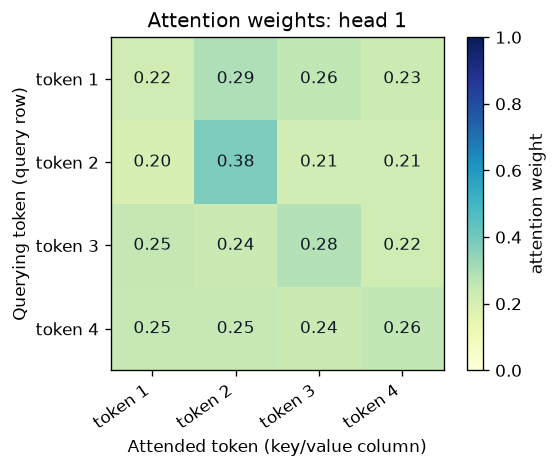

In [5]:
def plot_attention_matrix(matrix, title, filename):
    fig, ax = plt.subplots(figsize=(5, 4))
    values = matrix.detach().cpu()
    image = ax.imshow(values, vmin=0, vmax=1, cmap='YlGnBu')
    for row in range(seq_len):
        for column in range(seq_len):
            color = 'white' if values[row, column] > 0.55 else '#111827'
            ax.text(column, row, f'{values[row, column]:.2f}', ha='center', va='center', color=color)
    ax.set_xticks(range(seq_len), tokens, rotation=35, ha='right')
    ax.set_yticks(range(seq_len), tokens)
    ax.set_xlabel('Attended token (key/value column)')
    ax.set_ylabel('Querying token (query row)')
    ax.set_title(title)
    fig.colorbar(image, ax=ax, label='attention weight')
    fig.tight_layout()
    fig.savefig(figures_dir / filename, bbox_inches='tight')
    return fig

plot_attention_matrix(weights[0, 0], 'Attention weights: head 1', 'attention-weights.png');

## 6. What scaling changes

For several key dimensions, this simulation samples random queries and keys. It compares the variance of raw dot-product scores with scaled scores, then measures the entropy of their softmax distributions.

On the left, the variance axis is logarithmic so both curves remain visible: a flat scaled curve near `1` means the score spread stays stable. On the right, entropy measures how spread out a softmax row is. Higher entropy means attention is shared more evenly; lower entropy means it concentrates on fewer keys. With eight possible keys, `log(8)` is the largest possible entropy and appears as a dashed reference line. This is an observation about the score scale in this controlled setup, not a proof about full Transformer training.

In [6]:
torch.manual_seed(11)
dimensions = [4, 16, 64, 256]
trials, keys_per_query = 512, 8
scaling_results = []

for d_k in dimensions:
    queries = torch.randn(trials, d_k)
    keys = torch.randn(trials, keys_per_query, d_k)
    unscaled_scores = (queries.unsqueeze(1) * keys).sum(dim=-1)
    scaled_scores = unscaled_scores / math.sqrt(d_k)

    unscaled_entropy = -(torch.softmax(unscaled_scores, dim=-1) * torch.log_softmax(unscaled_scores, dim=-1)).sum(dim=-1).mean()
    scaled_entropy = -(torch.softmax(scaled_scores, dim=-1) * torch.log_softmax(scaled_scores, dim=-1)).sum(dim=-1).mean()
    scaling_results.append((d_k, unscaled_scores.var().item(), scaled_scores.var().item(), unscaled_entropy.item(), scaled_entropy.item()))

print('d_k | unscaled variance | scaled variance | unscaled entropy | scaled entropy')
for result in scaling_results:
    print(f'{result[0]:>3} | {result[1]:>17.3f} | {result[2]:>15.3f} | {result[3]:>16.3f} | {result[4]:>14.3f}')

d_k | unscaled variance | scaled variance | unscaled entropy | scaled entropy
  4 |             3.966 |           0.992 |            1.302 |          1.754
 16 |            16.301 |           1.019 |            0.646 |          1.722
 64 |            64.467 |           1.007 |            0.314 |          1.717
256 |           252.116 |           0.985 |            0.162 |          1.720


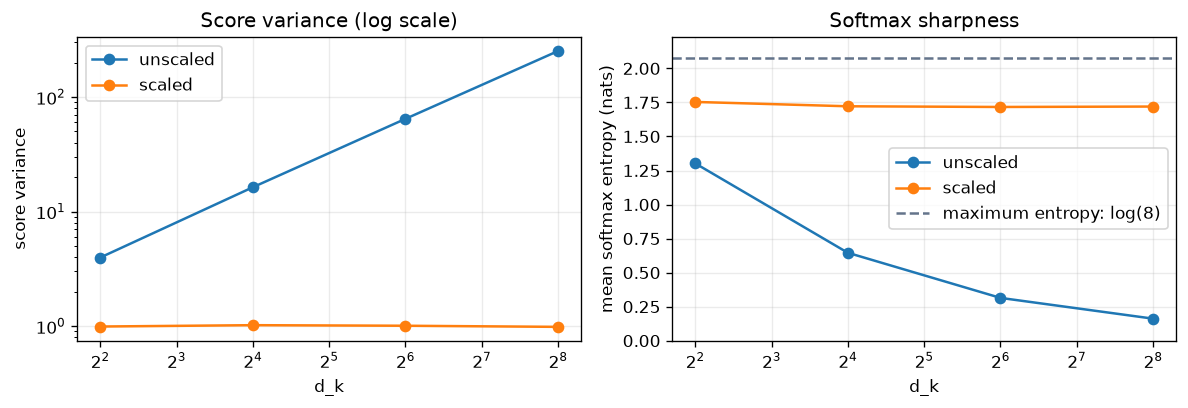

In [7]:
d_k_values = [result[0] for result in scaling_results]
unscaled_variances = [result[1] for result in scaling_results]
scaled_variances = [result[2] for result in scaling_results]
unscaled_entropies = [result[3] for result in scaling_results]
scaled_entropies = [result[4] for result in scaling_results]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(d_k_values, unscaled_variances, marker='o', label='unscaled')
axes[0].plot(d_k_values, scaled_variances, marker='o', label='scaled')
axes[0].set_xscale('log', base=2)
axes[0].set_yscale('log')
axes[0].set_xlabel('d_k')
axes[0].set_ylabel('score variance')
axes[0].set_title('Score variance (log scale)')
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(d_k_values, unscaled_entropies, marker='o', label='unscaled')
axes[1].plot(d_k_values, scaled_entropies, marker='o', label='scaled')
axes[1].set_xscale('log', base=2)
axes[1].axhline(math.log(keys_per_query), color='#64748b', linestyle='--', label='maximum entropy: log(8)')
axes[1].set_xlabel('d_k')
axes[1].set_ylabel('mean softmax entropy (nats)')
axes[1].set_title('Softmax sharpness')
axes[1].set_ylim(0, math.log(keys_per_query) + 0.15)
axes[1].grid(alpha=0.25)
axes[1].legend()

fig.tight_layout()
fig.savefig(figures_dir / 'scaling-comparison.png', bbox_inches='tight')
plt.show()

## 7. Causal masking

A decoder uses a lower-triangular mask before softmax. At position 1 it can use position 1; at position 2 it can use positions 1–2; later positions can use only themselves and earlier positions.

In the right-hand plot, each hatched cell is a future token. It is blocked before softmax, so its displayed weight is exactly `0.00`; it is not simply a token that received a small amount of attention.

In [8]:
one_head_Q, one_head_K, one_head_V = Q[:, :1], K[:, :1], V[:, :1]
causal_mask = torch.tril(torch.ones(seq_len, seq_len, dtype=torch.bool)).view(1, 1, seq_len, seq_len)

_, unmasked_weights, _ = scaled_dot_product_attention(one_head_Q, one_head_K, one_head_V)
_, masked_weights, _ = scaled_dot_product_attention(one_head_Q, one_head_K, one_head_V, causal_mask)
future_weights = masked_weights[0, 0].triu(diagonal=1)

print('Largest future-token weight after masking:', future_weights.max().item())
print('Masked attention rows sum to 1:', torch.allclose(masked_weights.sum(dim=-1), torch.ones_like(masked_weights.sum(dim=-1))))
assert future_weights.max().item() == 0.0

Largest future-token weight after masking: 0.0
Masked attention rows sum to 1: True


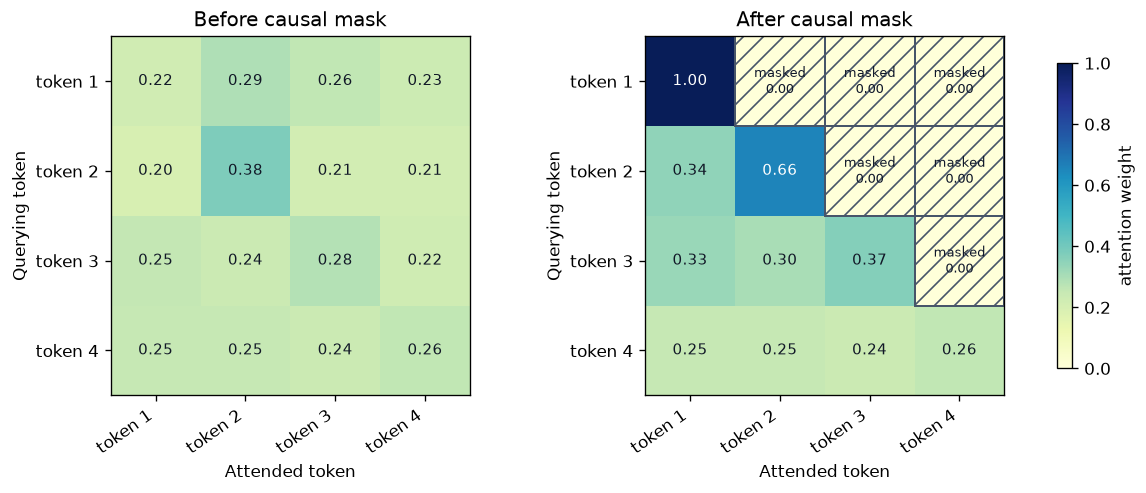

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
for ax, matrix, title in zip(axes, [unmasked_weights[0, 0], masked_weights[0, 0]], ['Before causal mask', 'After causal mask']):
    values = matrix.detach().cpu()
    image = ax.imshow(values, vmin=0, vmax=1, cmap='YlGnBu')
    for row in range(seq_len):
        for column in range(seq_len):
            is_future = title == 'After causal mask' and column > row
            if is_future:
                ax.add_patch(Rectangle((column - 0.5, row - 0.5), 1, 1, fill=False, hatch='//', edgecolor='#475569', linewidth=1.2))
                ax.text(column, row, 'masked\n0.00', ha='center', va='center', fontsize=8, color='#0f172a')
            else:
                color = 'white' if values[row, column] > 0.55 else '#111827'
                ax.text(column, row, f'{values[row, column]:.2f}', ha='center', va='center', fontsize=9, color=color)
    ax.set_xticks(range(seq_len), tokens, rotation=35, ha='right')
    ax.set_yticks(range(seq_len), tokens)
    ax.set_xlabel('Attended token')
    ax.set_ylabel('Querying token')
    ax.set_title(title)
fig.colorbar(image, ax=axes, label='attention weight', shrink=0.85)
fig.savefig(figures_dir / 'causal-mask.png', bbox_inches='tight')
plt.show()

## 8. Extending to multiple heads

The first calculation already used two heads. Here the per-head outputs are transposed back, concatenated into `d_model`, then passed through one output projection. The shape changes make the split-and-recombine step explicit.

In [10]:
output_projection = nn.Linear(d_model, d_model, bias=False)

# output: [batch, heads, seq_len, d_head]
combined_heads = output.transpose(1, 2).contiguous().view(batch_size, seq_len, d_model)
# final_output: [batch, seq_len, d_model]
final_output = output_projection(combined_heads)

print(f'Q/K/V: {list(Q.shape)}  = [batch, heads, seq_len, d_head]')
print(f'scores: {list(scores.shape)}  = [batch, heads, seq_len, seq_len]')
print(f'per-head output: {list(output.shape)}')
print(f'concatenated heads: {list(combined_heads.shape)}')
print(f'final output: {list(final_output.shape)}  = [batch, seq_len, d_model]')

assert final_output.shape == (batch_size, seq_len, d_model)

Q/K/V: [1, 2, 4, 4]  = [batch, heads, seq_len, d_head]
scores: [1, 2, 4, 4]  = [batch, heads, seq_len, seq_len]
per-head output: [1, 2, 4, 4]
concatenated heads: [1, 4, 8]
final output: [1, 4, 8]  = [batch, seq_len, d_model]


## 9. What I learned

- Q, K, and V are learned linear views of the same input, not three different input sequences.
- `QKᵀ` produces one score per query/key pair; softmax turns every query row into a distribution over value positions. The row annotations make that distribution visible.
- In this random simulation, dividing by `√d_k` kept score variance closer to one as `d_k` grew and kept entropy close to the eight-key maximum, rather than forcing a very sharp softmax.
- Applying the causal mask before softmax made every hatched future-position cell exactly zero.
- Multi-head attention is the same operation on several smaller representation subspaces, followed by concatenation and a projection.